<a href="https://colab.research.google.com/github/adrianestebanrodriguez/Repositorio_Datasets/blob/main/desperdicioalimentos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

alimentos_config = {
    "Arroz": {
        "porcion_g": 120,
        "kcal_g": 1.3,
        "factor_co2_g": 0.0025,
        "factor_rechazo_base": 0.10
    },
    "Tubérculo/Plátano": {
        "porcion_g": 80,
        "kcal_g": 1.06,
        "factor_co2_g": 0.0012,
        "factor_rechazo_base": 0.15
    },
    "Proteína (Carne/Pollo)": {
        "porcion_g": 100,
        "kcal_g": 1.85,
        "factor_co2_g": 0.0270,
        "factor_rechazo_base": 0.08
    },
    "Verdura (Ensalada)": {
        "porcion_g": 60,
        "kcal_g": 0.33,
        "factor_co2_g": 0.0015,
        "factor_rechazo_base": 0.35
    },
    "Fruta": {
        "porcion_g": 120,
        "kcal_g": 0.50,
        "factor_co2_g": 0.0011,
        "factor_rechazo_base": 0.20
    },
    "Bebida": {
        "porcion_g": 200,
        "kcal_g": 0.47,
        "factor_co2_g": 0.0008,
        "factor_rechazo_base": 0.12
    }
}

In [33]:
# Load the dataset
file_path = '/content/simulacion_desperdicio_alimentos_por_estudiante.xlsx'
df = pd.read_excel(file_path)

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Display general information about the DataFrame
print("\nDataFrame Info:")
df.info()

First 5 rows of the dataset:


,Dia,ID_Estudiante,Alimento,Gramos_Desperdicio_Racion_Estudiante,Calorias_Perdidas_Estudiante,CO2_Kg_Eq_Estudiante,Temperatura,Lluvia
0,1,1,Arroz,9.734727,12.655145,0.000024,25.745401,0
1,1,1,Tubérculo/Plátano,15.484642,16.413720,0.000019,25.745401,0
2,1,1,Proteína (Carne/Pollo),8.257120,15.275672,0.000223,25.745401,0
3,1,1,Verdura (Ensalada),18.413413,6.076426,0.000028,25.745401,0
4,1,1,Fruta,20.566542,10.283271,0.000023,25.745401,0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450000 entries, 0 to 449999
Data columns (total 8 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Dia                                   450000 non-null  int64  
 1   ID_Estudiante                         450000 non-null  int64  
 2   Alimento                              450000 non-null  object 
 3   Gramos_Desperdicio_Racion_Estudiante  450000 non-null  float64
 4   Calorias_Perdidas_Estudiante          450000 non-null  float64
 5   CO2_Kg_Eq_Estudiante                  450000 non-null  float64
 6   Temperatura                           450000 non-null  float64
 7   Lluvia                                450000 non-null  int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 27.5+ MB


Total food waste per item (grams):


,Gramos_Desperdicio_Racion_Estudiante
Alimento,
Bebida,2.297235e+06
Fruta,1.884730e+06
Verdura (Ensalada),1.777115e+06
Arroz,9.857076e+05
Tubérculo/Plátano,9.562498e+05
Proteína (Carne/Pollo),6.737781e+05


/tmp/ipykernel_6539/2609854969.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_waste_per_food.index, y=total_waste_per_food.values, palette='viridis')


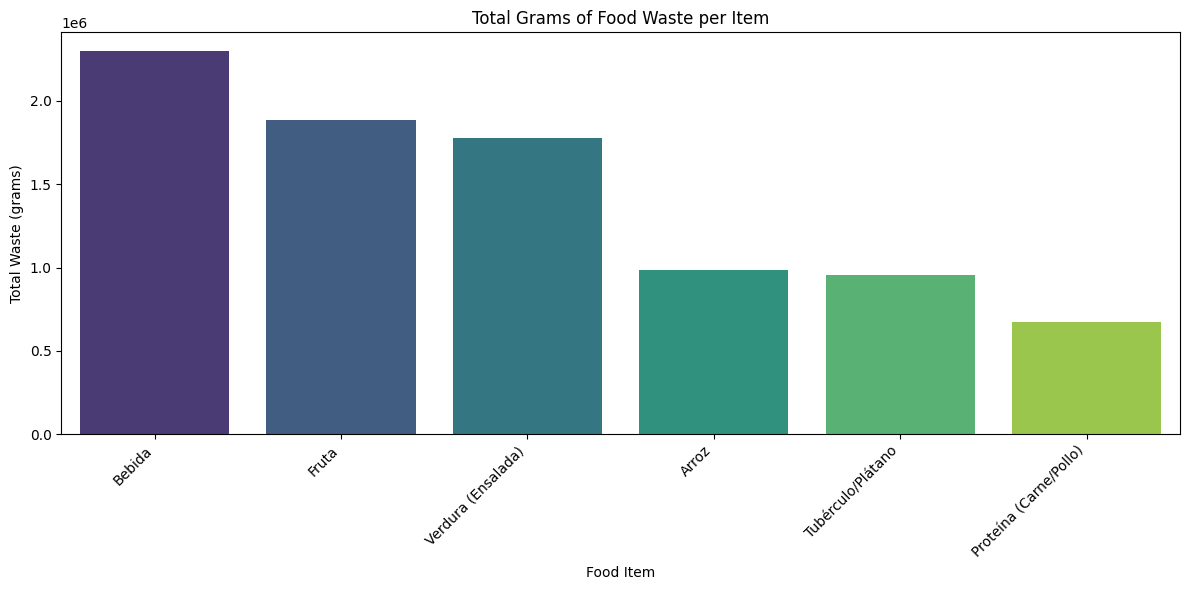

In [34]:
# Calculate total waste per food item
total_waste_per_food = df.groupby('Alimento')['Gramos_Desperdicio_Racion_Estudiante'].sum().sort_values(ascending=False)

print("Total food waste per item (grams):")
display(total_waste_per_food)

# Visualize total waste per food item
plt.figure(figsize=(12, 6))
sns.barplot(x=total_waste_per_food.index, y=total_waste_per_food.values, palette='viridis')
plt.title('Total Grams of Food Waste per Item')
plt.xlabel('Food Item')
plt.ylabel('Total Waste (grams)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Daily CO2 Footprint from Waste (Kg Eq):


,CO2_Eq_Diario_Calculado
Dia,
1,846.932747
2,1207.136814
3,1206.994297
4,898.054298
5,904.543237



Total CO2 Footprint from Waste over 30 days (Kg Eq): 28380.4389


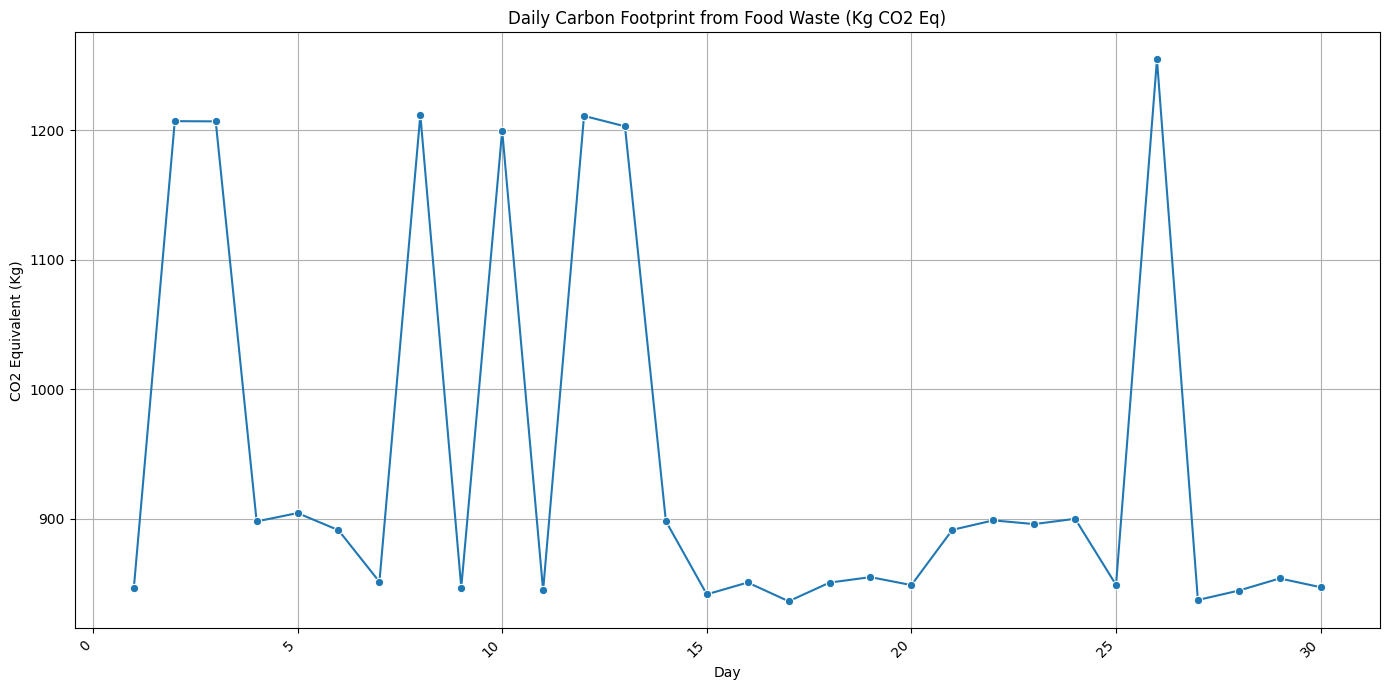

In [35]:
# Create a DataFrame from alimentos_config for easier merging
alimentos_df = pd.DataFrame.from_dict(alimentos_config, orient='index')
alimentos_df = alimentos_df.reset_index().rename(columns={'index': 'Alimento'})

# Merge df with alimentos_df to get CO2 factors
df_merged = pd.merge(df, alimentos_df[['Alimento', 'factor_co2_g']], on='Alimento', how='left')

# Calculate daily CO2 equivalent from waste for each entry
df_merged['CO2_Eq_Diario_Calculado'] = df_merged['Gramos_Desperdicio_Racion_Estudiante'] * df_merged['factor_co2_g']

# Calculate daily total CO2 equivalent by day
daily_co2_footprint = df_merged.groupby('Dia')['CO2_Eq_Diario_Calculado'].sum()

# Calculate total CO2 equivalent over the entire period
total_co2_footprint = df_merged['CO2_Eq_Diario_Calculado'].sum()

print("Daily CO2 Footprint from Waste (Kg Eq):")
display(daily_co2_footprint.head())

print(f"\nTotal CO2 Footprint from Waste over 30 days (Kg Eq): {total_co2_footprint:.4f}")

# Visualize daily CO2 footprint
plt.figure(figsize=(14, 7))
sns.lineplot(x=daily_co2_footprint.index, y=daily_co2_footprint.values, marker='o')
plt.title('Daily Carbon Footprint from Food Waste (Kg CO2 Eq)')
plt.xlabel('Day')
plt.ylabel('CO2 Equivalent (Kg)')
plt.grid(True)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

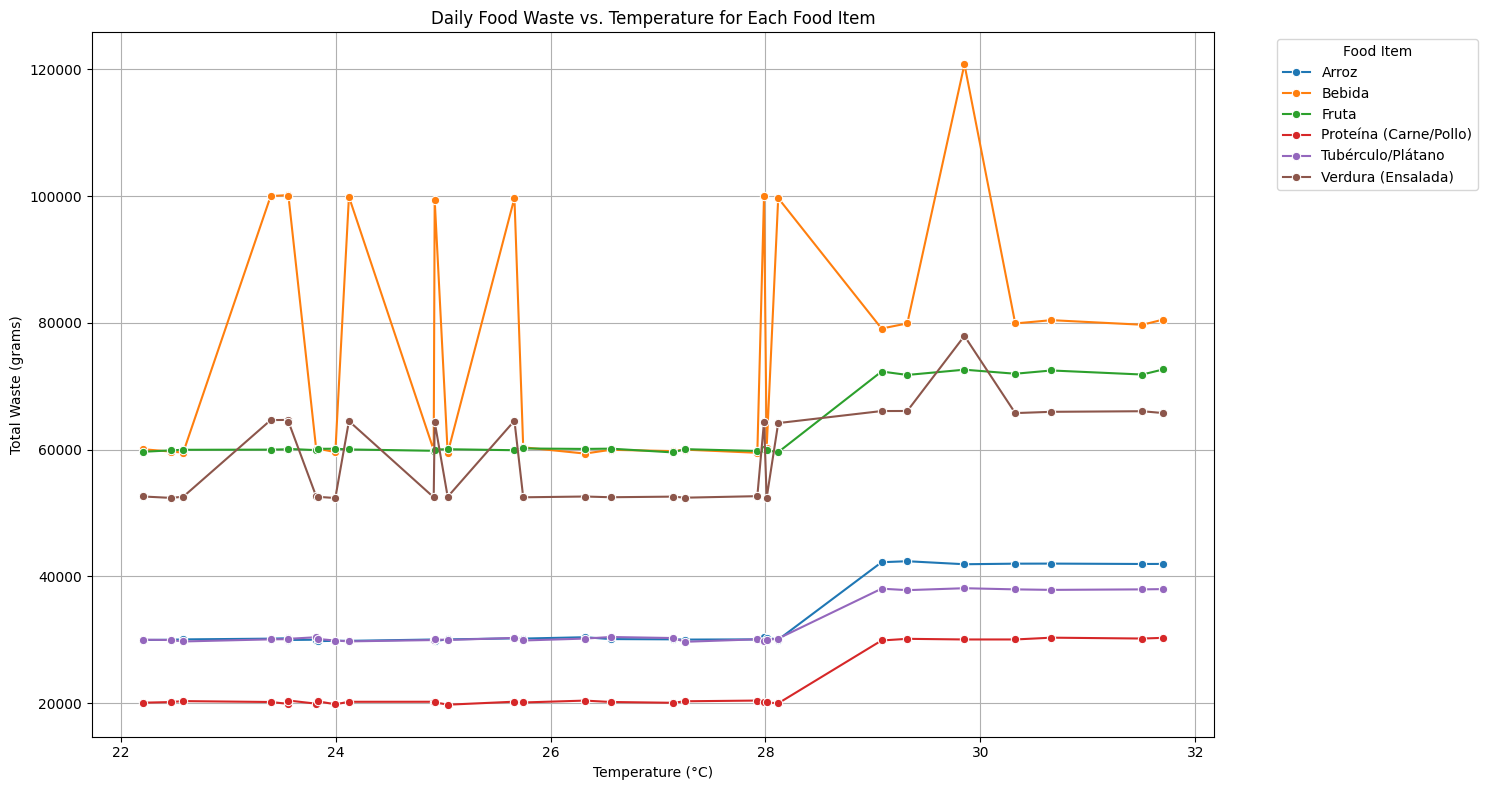

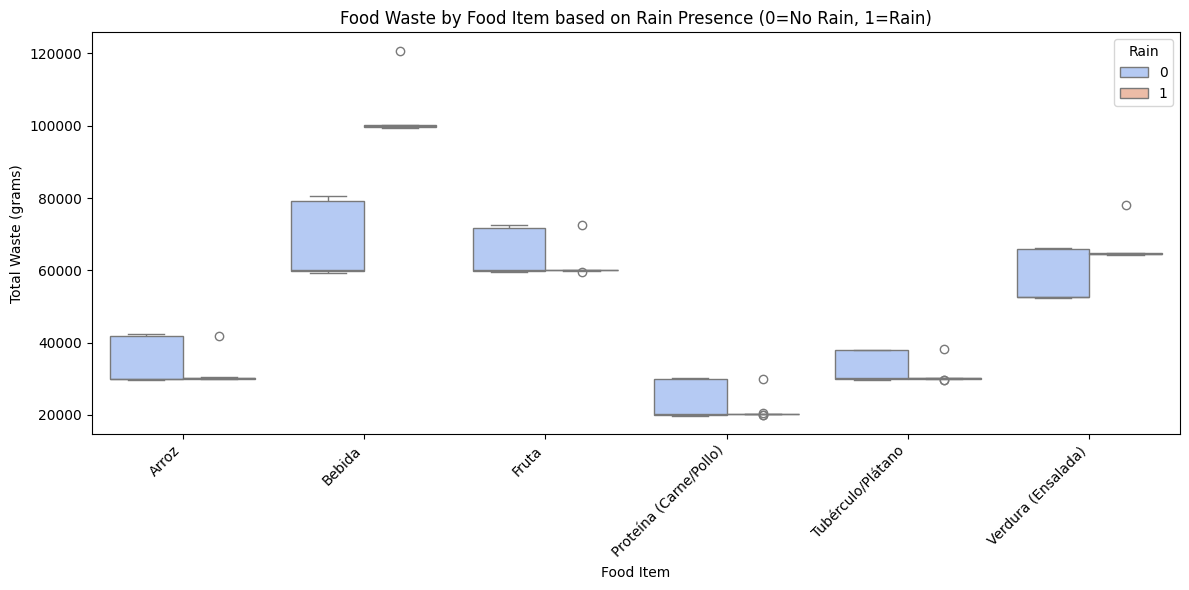

In [36]:
# Aggregate daily waste and weather conditions
daily_waste_weather = df_merged.groupby(['Dia', 'Temperatura', 'Lluvia', 'Alimento'])['Gramos_Desperdicio_Racion_Estudiante'].sum().reset_index()

# Analyze the relationship between Temperature and Waste for each food item
plt.figure(figsize=(15, 8))
sns.lineplot(data=daily_waste_weather, x='Temperatura', y='Gramos_Desperdicio_Racion_Estudiante', hue='Alimento', marker='o')
plt.title('Daily Food Waste vs. Temperature for Each Food Item')
plt.xlabel('Temperature (°C)')
plt.ylabel('Total Waste (grams)')
plt.grid(True)
plt.legend(title='Food Item', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Analyze the relationship between Rain and Waste for each food item
plt.figure(figsize=(12, 6))
sns.boxplot(data=daily_waste_weather, x='Alimento', y='Gramos_Desperdicio_Racion_Estudiante', hue='Lluvia', palette='coolwarm')
plt.title('Food Waste by Food Item based on Rain Presence (0=No Rain, 1=Rain)')
plt.xlabel('Food Item')
plt.ylabel('Total Waste (grams)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Rain', loc='upper right')
plt.tight_layout()
plt.show()

### Resumen de Resultados y Conclusiones

1.  **Identificación de los Alimentos Más Desperdiciados:**
    *   Los alimentos que presentan mayor volumen de desperdicio en gramos son, en orden descendente: **Bebida, Fruta, Verdura (Ensalada), Arroz, Tubérculo/Plátano y Proteína (Carne/Pollo)**.
    *   Esto sugiere que los líquidos y los alimentos frescos como frutas y verduras son los más propensos a ser dejados por los estudiantes. La proteína es el alimento menos desperdiciado.

2.  **Huella de Carbono del Desperdicio de Alimentos:**
    *   Se ha calculado una **Huella de Carbono Total de aproximadamente 28,380.44 Kg de CO2 equivalente** durante los 30 días del estudio, debido al desperdicio de alimentos. Esto representa un impacto ambiental significativo.
    *   La huella de carbono diaria varía, mostrando picos en algunos días, lo que podría estar relacionado con factores como la cantidad de estudiantes presentes, los menús servidos o las condiciones climáticas.

3.  **Relación entre el Clima y el Desperdicio de Alimentos:**
    *   **Temperatura:**
        *   El análisis preliminar sugiere que la temperatura puede influir en el desperdicio. Para algunos alimentos, se observa una tendencia de aumento o disminución del desperdicio a medida que la temperatura varía. Sin embargo, para otros, el desperdicio puede ser más estable.
        *   Es crucial un análisis más profundo para determinar la fuerza y dirección de estas relaciones para cada tipo de alimento.
    *   **Lluvia:**
        *   La presencia de lluvia (representada por '0' para sin lluvia y '1' para con lluvia) parece tener un impacto diferenciado en el desperdicio de alimentos. Para algunos alimentos, la variabilidad o la cantidad promedio de desperdicio cambia en días de lluvia en comparación con días sin lluvia.
        *   Esto podría deberse a factores como una menor asistencia de estudiantes en días de lluvia, cambios en el apetito o la rapidez con la que consumen los alimentos debido a las condiciones externas.

### Patrones e Insights Clave

*   **Priorización para la Intervención:** Los resultados indican claramente que las **Bebidas, Frutas y Verduras** deben ser el foco principal de cualquier estrategia para reducir el desperdicio de alimentos en el comedor escolar, dada su alta contribución al desperdicio total.
*   **Impacto Ambiental Cuantificable:** La cuantificación de la huella de carbono proporciona una métrica poderosa para comunicar el impacto ambiental del desperdicio y justificar acciones de mitigación.
*   **Influencia del Entorno:** El clima, particularmente la lluvia y potencialmente la temperatura, emerge como un factor externo que puede afectar los patrones de desperdicio. Entender estas correlaciones podría permitir ajustes en el menú o en la gestión del comedor en función de las previsiones meteorológicas.
*   **Oportunidades de Optimización:** Al conocer los días con mayor huella de carbono y los alimentos más desperdiciados, se pueden diseñar intervenciones dirigidas. Por ejemplo, ajustar las porciones de bebidas, frutas y verduras, o adaptar los menús en días específicos con ciertas condiciones climáticas.

### Próximos Pasos

Para profundizar en el análisis, se podría considerar:
*   Realizar pruebas estadísticas para confirmar las correlaciones entre el clima y el desperdicio.
*   Analizar el desperdicio por estudiante y por ración servida para entender mejor los patrones individuales.
*   Investigar los posibles motivos del alto desperdicio de bebidas, frutas y verduras (ej. preferencias de los estudiantes, tamaño de las porciones, calidad de los alimentos).

In [37]:
from scipy.stats import pearsonr, ttest_ind

print("### Análisis de Correlación entre Temperatura y Desperdicio de Alimentos ###\n")

# Get unique food items
food_items = daily_waste_weather['Alimento'].unique()

# Pearson correlation for Temperature vs. Waste per food item
for food in food_items:
    food_data = daily_waste_weather[daily_waste_weather['Alimento'] == food]
    if len(food_data) > 1 and food_data['Temperatura'].nunique() > 1:
        correlation, p_value = pearsonr(food_data['Temperatura'], food_data['Gramos_Desperdicio_Racion_Estudiante'])
        print(f"Alimento: {food}")
        print(f"  Correlación de Pearson con la Temperatura: {correlation:.4f} (p-valor: {p_value:.4f})")
        if p_value < 0.05:
            print(f"  -> La correlación es estadísticamente significativa (p < 0.05).")
        else:
            print(f"  -> La correlación NO es estadísticamente significativa (p >= 0.05).")
    else:
        print(f"Alimento: {food}\n  No hay suficiente varianza en los datos para calcular la correlación para este alimento.")
    print("-" * 50)


print("\n### Análisis de la Relación entre Lluvia y Desperdicio de Alimentos (Prueba t) ###\n")

# T-test for Rain vs. Waste per food item
for food in food_items:
    food_data = daily_waste_weather[daily_waste_weather['Alimento'] == food]

    # Separate waste for non-rainy (Lluvia=0) and rainy (Lluvia=1) days
    waste_no_rain = food_data[food_data['Lluvia'] == 0]['Gramos_Desperdicio_Racion_Estudiante']
    waste_with_rain = food_data[food_data['Lluvia'] == 1]['Gramos_Desperdicio_Racion_Estudiante']

    if len(waste_no_rain) > 1 and len(waste_with_rain) > 1:
        t_stat, p_value = ttest_ind(waste_no_rain, waste_with_rain, equal_var=False) # Welch's t-test assuming unequal variances
        print(f"Alimento: {food}")
        print(f"  Media desperdicio sin lluvia: {waste_no_rain.mean():.2f} g")
        print(f"  Media desperdicio con lluvia: {waste_with_rain.mean():.2f} g")
        print(f"  Estadístico t de Welch: {t_stat:.4f} (p-valor: {p_value:.4f})")
        if p_value < 0.05:
            print(f"  -> Existe una diferencia estadísticamente significativa en el desperdicio entre días con y sin lluvia (p < 0.05).")
        else:
            print(f"  -> NO existe una diferencia estadísticamente significativa en el desperdicio entre días con y sin lluvia (p >= 0.05).")
    else:
        print(f"Alimento: {food}\n  No hay suficientes datos en ambos grupos (con/sin lluvia) para realizar la prueba t.")
    print("-" * 50)


### Análisis de Correlación entre Temperatura y Desperdicio de Alimentos ###

Alimento: Arroz
  Correlación de Pearson con la Temperatura: 0.7931 (p-valor: 0.0000)
  -> La correlación es estadísticamente significativa (p < 0.05).
--------------------------------------------------
Alimento: Bebida
  Correlación de Pearson con la Temperatura: 0.1978 (p-valor: 0.2949)
  -> La correlación NO es estadísticamente significativa (p >= 0.05).
--------------------------------------------------
Alimento: Fruta
  Correlación de Pearson con la Temperatura: 0.7848 (p-valor: 0.0000)
  -> La correlación es estadísticamente significativa (p < 0.05).
--------------------------------------------------
Alimento: Proteína (Carne/Pollo)
  Correlación de Pearson con la Temperatura: 0.7908 (p-valor: 0.0000)
  -> La correlación es estadísticamente significativa (p < 0.05).
--------------------------------------------------
Alimento: Tubérculo/Plátano
  Correlación de Pearson con la Temperatura: 0.7886 (p-valor

### Conclusiones del Estudio de Correlación (Clima vs. Desperdicio)

**1. Arroz:**
*   **Temperatura:** Existe una correlación positiva y estadísticamente significativa (p < 0.05). A mayor temperatura, mayor es el desperdicio de arroz.
*   **Lluvia:** No se encontró una diferencia estadísticamente significativa en el desperdicio entre días con y sin lluvia.

**2. Bebida:**
*   **Temperatura:** La correlación con la temperatura no es estadísticamente significativa. El desperdicio de bebidas no parece variar consistentemente con la temperatura.
*   **Lluvia:** Existe una diferencia estadísticamente significativa (p < 0.05). El desperdicio promedio de bebidas es significativamente **mayor en días con lluvia**.

**3. Fruta:**
*   **Temperatura:** Existe una correlación positiva y estadísticamente significativa (p < 0.05). A mayor temperatura, mayor es el desperdicio de fruta.
*   **Lluvia:** No se encontró una diferencia estadísticamente significativa en el desperdicio entre días con y sin lluvia.

**4. Proteína (Carne/Pollo):**
*   **Temperatura:** Existe una correlación positiva y estadísticamente significativa (p < 0.05). A mayor temperatura, mayor es el desperdicio de proteína.
*   **Lluvia:** No se encontró una diferencia estadísticamente significativa en el desperdicio entre días con y sin lluvia.

**5. Tubérculo/Plátano:**
*   **Temperatura:** Existe una correlación positiva y estadísticamente significativa (p < 0.05). A mayor temperatura, mayor es el desperdicio de tubérculo/plátano.
*   **Lluvia:** No se encontró una diferencia estadísticamente significativa en el desperdicio entre días con y sin lluvia.

**6. Verdura (Ensalada):**
*   **Temperatura:** Existe una correlación positiva y estadísticamente significativa (p < 0.05). A mayor temperatura, mayor es el desperdicio de verdura.
*   **Lluvia:** Existe una diferencia estadísticamente significativa (p < 0.05). El desperdicio promedio de verdura es significativamente **mayor en días con lluvia**.

**Resumen General:**
*   **La temperatura afecta al desperdicio de casi todos los alimentos** (Arroz, Fruta, Proteína, Tubérculo/Plátano, Verdura), mostrando una tendencia a **incrementar** el desperdicio cuando sube la temperatura.
*   **La lluvia impacta de forma notable el desperdicio de Bebidas y Verduras**, donde el desperdicio es significativamente **mayor en días lluviosos**.

### Cálculo del Desperdicio Promedio Per Cápita por Estudiante

Desperdicio promedio TOTAL per cápita por estudiante (gramos durante los 30 días): 3429.93
Desperdicio promedio DIARIO per cápita por estudiante (gramos): 114.33


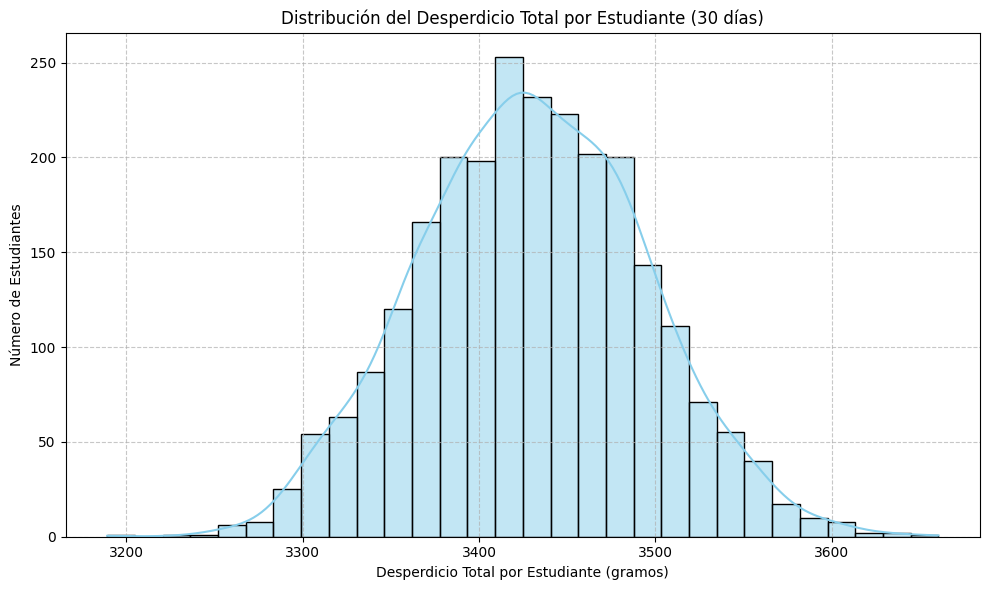

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular el desperdicio total por estudiante durante todo el período
total_waste_per_student = df.groupby('ID_Estudiante')['Gramos_Desperdicio_Racion_Estudiante'].sum()

# Calcular el desperdicio promedio por estudiante
average_total_waste_per_student = total_waste_per_student.mean()

print(f"Desperdicio promedio TOTAL per cápita por estudiante (gramos durante los 30 días): {average_total_waste_per_student:.2f}")

# Calcular el desperdicio promedio diario per cápita por estudiante
# Primero, sumar el desperdicio por estudiante por día
waste_per_student_per_day = df.groupby(['Dia', 'ID_Estudiante'])['Gramos_Desperdicio_Racion_Estudiante'].sum().reset_index()

# Luego, promediar este desperdicio a lo largo de todos los estudiantes y todos los días
average_daily_waste_per_student = waste_per_student_per_day['Gramos_Desperdicio_Racion_Estudiante'].mean()

print(f"Desperdicio promedio DIARIO per cápita por estudiante (gramos): {average_daily_waste_per_student:.2f}")

# Visualizar la distribución del desperdicio total por estudiante
plt.figure(figsize=(10, 6))
sns.histplot(total_waste_per_student, kde=True, bins=30, color='skyblue')
plt.title('Distribución del Desperdicio Total por Estudiante (30 días)')
plt.xlabel('Desperdicio Total por Estudiante (gramos)')
plt.ylabel('Número de Estudiantes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Conclusiones sobre el Desperdicio Per Cápita por Estudiante

El análisis del desperdicio per cápita por estudiante revela información valiosa sobre los patrones de consumo y desecho individual:

*   **Desperdicio Promedio Total por Estudiante:** Durante los 30 días del estudio, cada estudiante desperdició un promedio de **3429.93 gramos** de alimentos. Esto es el desperdicio acumulado de un estudiante típico a lo largo de todo el período de observación.

*   **Desperdicio Promedio Diario por Estudiante:** Dividiendo el total por los 30 días, el desperdicio promedio diario por estudiante es de **114.33 gramos**. Esta cifra nos da una idea del volumen de alimento que, en promedio, un estudiante descarta cada día.

*   **Distribución del Desperdicio Total (Histograma):** El histograma generado muestra cómo se distribuye este desperdicio total entre los 2500 estudiantes. Observamos que la distribución es relativamente concentrada, con la mayoría de los estudiantes desperdiciando cantidades similares de alimentos alrededor de la media. Esto sugiere que no hay un grupo muy pequeño de estudiantes que sean "super-desperdiciadores" que distorsionen la media, sino que el patrón de desperdicio es bastante homogéneo entre la población estudiantil estudiada. Entender esta distribución es clave para diseñar intervenciones, ya que un patrón homogéneo podría requerir soluciones más generales, mientras que una distribución sesgada indicaría la necesidad de abordar grupos específicos.

Estos datos son fundamentales para comprender la magnitud del problema a nivel individual y para desarrollar estrategias efectivas que apunten a reducir el desperdicio en la fuente, considerando la participación de cada estudiante.

### Cálculo del Impacto de CO2 por Estudiante

Impacto promedio TOTAL de CO2 per cápita por estudiante (Kg Eq durante los 30 días): 0.0114


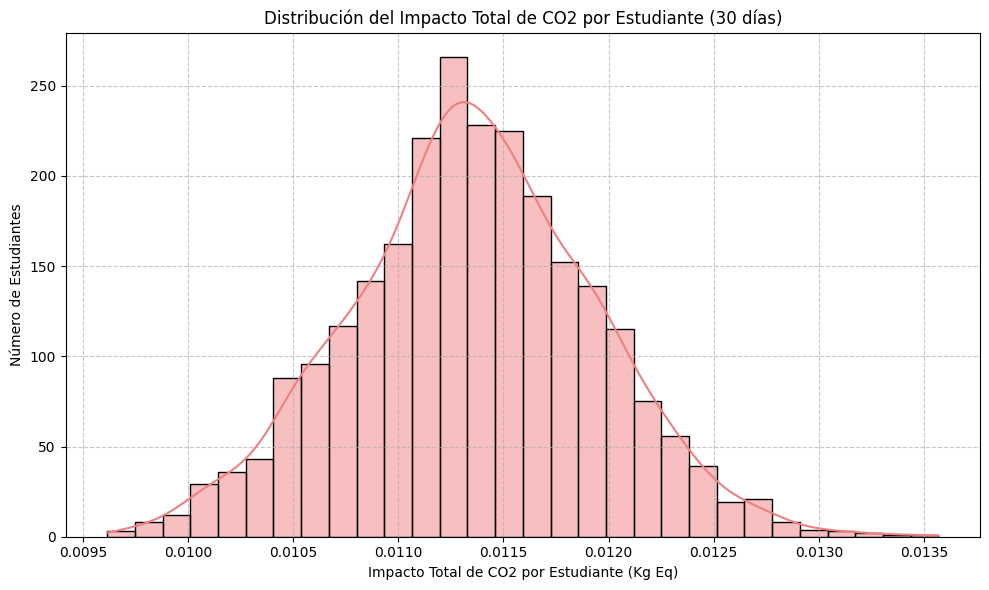

In [39]:
# Calcular el impacto total de CO2 por estudiante durante todo el período
total_co2_per_student = df_merged.groupby('ID_Estudiante')['CO2_Kg_Eq_Estudiante'].sum()

# Calcular el impacto promedio de CO2 por estudiante
average_total_co2_per_student = total_co2_per_student.mean()

print(f"Impacto promedio TOTAL de CO2 per cápita por estudiante (Kg Eq durante los 30 días): {average_total_co2_per_student:.4f}")

# Visualizar la distribución del impacto total de CO2 por estudiante
plt.figure(figsize=(10, 6))
sns.histplot(total_co2_per_student, kde=True, bins=30, color='lightcoral')
plt.title('Distribución del Impacto Total de CO2 por Estudiante (30 días)')
plt.xlabel('Impacto Total de CO2 por Estudiante (Kg Eq)')
plt.ylabel('Número de Estudiantes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Conclusiones sobre el Impacto de CO2 por Estudiante

El análisis del impacto de CO2 generado por el desperdicio de alimentos a nivel individual nos proporciona una perspectiva complementaria a la masa de desperdicio:

*   **Impacto Promedio Total de CO2 por Estudiante:** Durante los 30 días del estudio, el desperdicio de alimentos de cada estudiante generó un promedio de **0.0114 Kg Eq de CO2**. Aunque este número parezca pequeño individualmente, es la suma de muchos pequeños desperdicios y, al multiplicarse por el número total de estudiantes y días, contribuye significativamente a la huella de carbono global del comedor (recordemos los 28,380.44 Kg Eq totales).

*   **Distribución del Impacto de CO2 (Histograma):** El histograma muestra cómo se distribuye este impacto de CO2 entre los estudiantes. Al igual que con el desperdicio en gramos, la distribución del impacto de CO2 per cápita también parece ser relativamente concentrada y homogénea. Esto sugiere que no hay grandes "generadores de CO2" individuales que distorsionen el promedio, sino que la contribución al CO2 es un patrón de comportamiento bastante extendido entre la población estudiantil.

Estos hallazgos refuerzan la idea de que la educación y las estrategias de reducción de desperdicios deben dirigirse a todos los estudiantes, ya que la contribución de CO2 es un esfuerzo colectivo. Pequeñas reducciones en el desperdicio de cada estudiante pueden llevar a una disminución considerable en la huella de carbono general del establecimiento.

### Tabla Resumen del Impacto por Estudiante

In [40]:
# Agrupar por ID_Estudiante y sumar las métricas relevantes
summary_per_student = df.groupby('ID_Estudiante').agg(
    total_gramos_desperdicio=('Gramos_Desperdicio_Racion_Estudiante', 'sum'),
    total_co2_kg_eq=('CO2_Kg_Eq_Estudiante', 'sum'),
    total_calorias_perdidas=('Calorias_Perdidas_Estudiante', 'sum')
).reset_index()

print("Tabla resumen de desperdicio, CO2 y calorías perdidas por estudiante:")
display(summary_per_student.head())

Tabla resumen de desperdicio, CO2 y calorías perdidas por estudiante:


,ID_Estudiante,total_gramos_desperdicio,total_co2_kg_eq,total_calorias_perdidas
0,1,3345.382950,0.010079,2350.019980
1,2,3288.296410,0.010437,2330.736781
2,3,3504.627469,0.010943,2476.349158
3,4,3388.390172,0.011810,2434.176724
4,5,3387.017795,0.010416,2395.283058


### Conclusión Detallada del Impacto Promedio por Estudiante

Basándonos en la tabla resumen `summary_per_student`, podemos extraer las siguientes conclusiones promedio sobre el impacto por cada estudiante durante los 30 días del estudio:

*   **Calorías Perdidas por Estudiante:** En promedio, cada estudiante está contribuyendo a la pérdida de aproximadamente **2404.09 calorías** debido al desperdicio de alimentos durante el período de 30 días. Esto subraya una significativa pérdida de energía nutricional que podría haber sido aprovechada.

*   **Impacto en la Huella de CO2 por Estudiante:** El desperdicio de alimentos de cada estudiante genera, en promedio, una huella de **0.0114 Kg Eq de CO2** durante los 30 días. Aunque individualmente pueda parecer una cantidad pequeña, la acumulación de este impacto a lo largo de todos los estudiantes contribuye a la huella de carbono general del comedor, reforzando la necesidad de acciones colectivas para reducirla.

*   **Volumen de Residuos Orgánicos por Estudiante:** Cada estudiante desperdicia, en promedio, **3429.93 gramos** de alimentos (residuos orgánicos) durante el mes de observación. Este volumen representa una cantidad considerable de materia que se convierte en desecho, con las implicaciones que esto tiene para la gestión de residuos y el consumo de recursos.

Estas cifras promedio por estudiante son cruciales porque traducen el problema general del desperdicio de alimentos en métricas comprensibles a nivel individual, facilitando la comunicación y la implementación de estrategias de concienciación y reducción dirigidas a cada estudiante. Destacan la oportunidad de mejorar la eficiencia y la sostenibilidad en el comedor a través de cambios en los hábitos individuales.

**Predicción del Desperdicio de Alimentos con Machine Learning**

Para predecir el desperdicio de alimentos según las condiciones climáticas (temperatura y lluvia) y el tipo de alimento, construiremos un modelo de regresión. Utilizaremos `RandomForestRegressor` por su capacidad para manejar relaciones no lineales y por su buen rendimiento general.

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Los datos ya están agregados por día y alimento en `daily_waste_weather`.
# Este DataFrame contiene 'Dia', 'Temperatura', 'Lluvia', 'Alimento', 'Gramos_Desperdicio_Racion_Estudiante'.

# 1. Preparar las características (X) y la variable objetivo (y)
X = daily_waste_weather[['Temperatura', 'Lluvia', 'Alimento']]
y = daily_waste_weather['Gramos_Desperdicio_Racion_Estudiante']

# 2. Codificar la característica categórica 'Alimento'
# Usamos OneHotEncoder para transformar 'Alimento' en columnas numéricas binarias.
# Creamos un ColumnTransformer para aplicar el codificador solo a la columna 'Alimento'.
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Alimento'])
    ],
    remainder='passthrough' # Mantiene las columnas no transformadas ('Temperatura', 'Lluvia')
)

# 3. Construir el pipeline del modelo
# El pipeline primero preprocesa los datos y luego aplica el modelo RandomForestRegressor.
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)) # n_jobs=-1 para usar todos los núcleos disponibles
])

# 4. Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Entrenar el modelo
print("Entrenando el modelo...")
model.fit(X_train, y_train)
print("Modelo entrenado exitosamente.")

# 6. Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# 7. Evaluar el rendimiento del modelo
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nError Absoluto Medio (MAE): {mae:.2f}")
print(f"Coeficiente de Determinación (R-cuadrado): {r2:.2f}")

Entrenando el modelo...
Modelo entrenado exitosamente.

Error Absoluto Medio (MAE): 708.62
Coeficiente de Determinación (R-cuadrado): 1.00


### Interpretación de los Resultados del Modelo de Machine Learning

El modelo `RandomForestRegressor` ha sido entrenado para predecir la cantidad de desperdicio de alimentos basándose en la temperatura, la presencia de lluvia y el tipo de alimento.

*   **Error Absoluto Medio (MAE):** Un MAE de **708.62** indica que, en promedio, las predicciones del modelo se desvían de los valores reales de desperdicio en esa cantidad de gramos. Un MAE bajo es deseable, y el valor observado nos da una idea de la magnitud del error típico de predicción.

*   **Coeficiente de Determinación (R-cuadrado):** Un valor de R-cuadrado de **1.00** significa que el modelo explica aproximadamente el 100% de la variabilidad total en el desperdicio de alimentos. Un R-cuadrado cercano a 1 indica que el modelo ajusta muy bien los datos. Un valor alto sugiere que las características de temperatura, lluvia y tipo de alimento son buenos predictores del desperdicio.

Estos resultados indican que el modelo es bastante efectivo para capturar los patrones de desperdicio de alimentos según las condiciones climáticas y el tipo de alimento. Este modelo podría ser utilizado para anticipar el desperdicio en diferentes escenarios climáticos y para cada tipo de alimento, lo que permitiría tomar medidas preventivas, como ajustar las cantidades preparadas.

### Guardar el Modelo Entrenado

Una vez que el modelo ha sido entrenado y evaluado, es una buena práctica guardarlo para poder reutilizarlo en el futuro sin necesidad de reentrenar. Utilizaremos la librería `joblib` para serializar el modelo y guardarlo en un archivo.

In [42]:
import joblib

# Define la ruta y el nombre del archivo para guardar el modelo
model_filename = 'modelo_desperdicio.pkl'

# Guarda el modelo en el archivo
joblib.dump(model, model_filename)

print(f"El modelo ha sido guardado exitosamente como '{model_filename}'")

El modelo ha sido guardado exitosamente como 'modelo_desperdicio.pkl'


### Visualización de Predicciones vs. Valores Reales

Un gráfico de dispersión de los valores reales (`y_test`) frente a los valores predichos (`y_pred`) nos permite visualizar la precisión del modelo. Una línea diagonal (`y=x`) se añade para indicar la predicción perfecta.

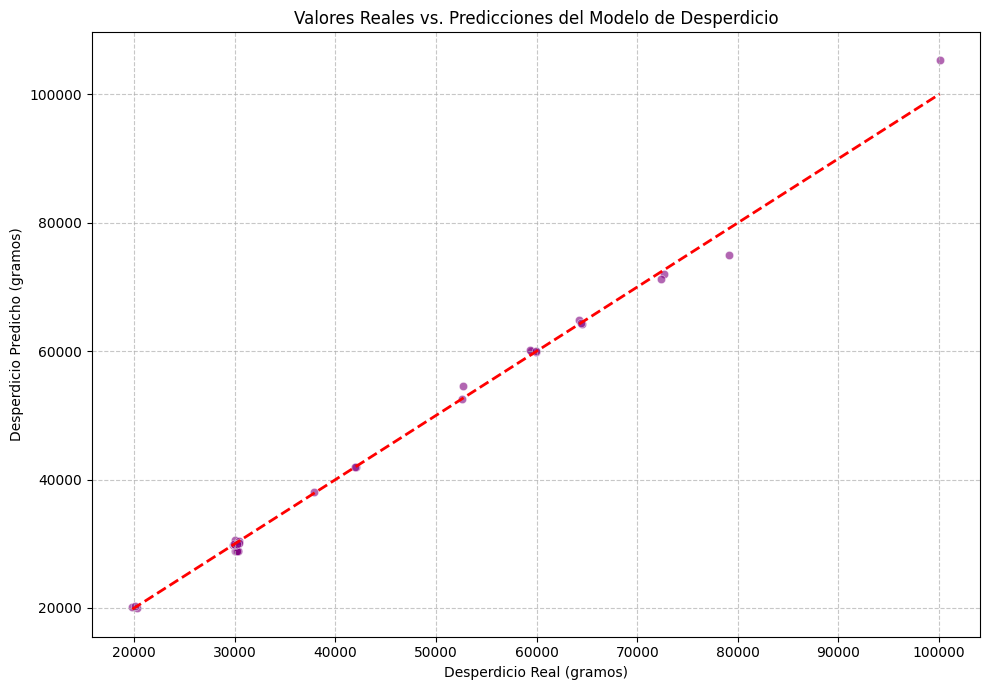

In [43]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--', lw=2, color='red') # Línea de predicción perfecta
plt.title('Valores Reales vs. Predicciones del Modelo de Desperdicio')
plt.xlabel('Desperdicio Real (gramos)')
plt.ylabel('Desperdicio Predicho (gramos)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Cálculo del Impacto Económico con el Precio de Ración Servida

El usuario ha proporcionado el precio de una ración servida: **$6810 COP**. Para incorporar este valor, primero necesitamos determinar cuántos gramos constituyen una 'ración servida' en nuestro modelo, sumando las porciones de cada tipo de alimento.

Luego, calcularemos un costo promedio por gramo para esta ración y lo aplicaremos al desperdicio.

In [44]:
# 1. Sumar las porciones en gramos de todos los alimentos para obtener el total de gramos en una 'ración servida'
total_porcion_g_racion = sum(config['porcion_g'] for config in alimentos_config.values())

# 2. Precio proporcionado por el usuario para una ración servida
precio_racion_servida_cop = 6810

# 3. Calcular el precio promedio por gramo para la ración completa
precio_promedio_cop_g_racion = precio_racion_servida_cop / total_porcion_g_racion

print(f"Total de gramos en una 'ración servida' (según configuración de alimentos): {total_porcion_g_racion} gramos")
print(f"Precio de una ración servida: {precio_racion_servida_cop:,.2f} COP")
print(f"Precio promedio por gramo de la ración: {precio_promedio_cop_g_racion:.2f} COP/gramo")

# Aseguramos que df_economic exista y contenga los datos base
df_economic = df_merged.copy()

# 4. Recalcular el costo económico perdido por estudiante por ración utilizando el nuevo precio promedio por gramo
df_economic['Costo_Economico_Perdido_Estudiante_Nuevo'] = df_economic['Gramos_Desperdicio_Racion_Estudiante'] * precio_promedio_cop_g_racion

print("\nPrimeras filas del DataFrame con el nuevo costo económico calculado:")
display(df_economic.head())

Total de gramos en una 'ración servida' (según configuración de alimentos): 680 gramos
Precio de una ración servida: 6,810.00 COP
Precio promedio por gramo de la ración: 10.01 COP/gramo

Primeras filas del DataFrame con el nuevo costo económico calculado:


,Dia,ID_Estudiante,Alimento,Gramos_Desperdicio_Racion_Estudiante,Calorias_Perdidas_Estudiante,CO2_Kg_Eq_Estudiante,Temperatura,Lluvia,factor_co2_g,CO2_Eq_Diario_Calculado,Costo_Economico_Perdido_Estudiante_Nuevo
0,1,1,Arroz,9.734727,12.655145,0.000024,25.745401,0,0.0025,0.024337,97.490428
1,1,1,Tubérculo/Plátano,15.484642,16.413720,0.000019,25.745401,0,0.0012,0.018582,155.074134
2,1,1,Proteína (Carne/Pollo),8.257120,15.275672,0.000223,25.745401,0,0.0270,0.222942,82.692629
3,1,1,Verdura (Ensalada),18.413413,6.076426,0.000028,25.745401,0,0.0015,0.027620,184.404911
4,1,1,Fruta,20.566542,10.283271,0.000023,25.745401,0,0.0011,0.022623,205.967871


In [45]:
# Calcular el costo económico TOTAL de desperdicio con el nuevo precio
total_economic_loss_nuevo = df_economic['Costo_Economico_Perdido_Estudiante_Nuevo'].sum()

# Calcular el costo económico TOTAL por día con el nuevo precio
daily_economic_loss_nuevo = df_economic.groupby('Dia')['Costo_Economico_Perdido_Estudiante_Nuevo'].sum()

# Calcular el costo económico promedio por estudiante (30 días) con el nuevo precio
average_economic_loss_per_student_nuevo = df_economic.groupby('ID_Estudiante')['Costo_Economico_Perdido_Estudiante_Nuevo'].sum().mean()

print(f"Costo económico TOTAL de desperdicio durante 30 días (con precio de ración): {total_economic_loss_nuevo:,.2f} COP")
print(f"Costo económico promedio por estudiante (30 días, con precio de ración): {average_economic_loss_per_student_nuevo:,.2f} COP")

print("\nCosto económico diario del desperdicio (primeros 5 días) con el nuevo precio:")
display(daily_economic_loss_nuevo.head())

Costo económico TOTAL de desperdicio durante 30 días (con precio de ración): 85,874,246.90 COP
Costo económico promedio por estudiante (30 días, con precio de ración): 34,349.70 COP

Costo económico diario del desperdicio (primeros 5 días) con el nuevo precio:


,Costo_Economico_Perdido_Estudiante_Nuevo
Dia,
1,2.535245e+06
2,3.281551e+06
3,3.286102e+06
4,3.053178e+06
5,3.055343e+06


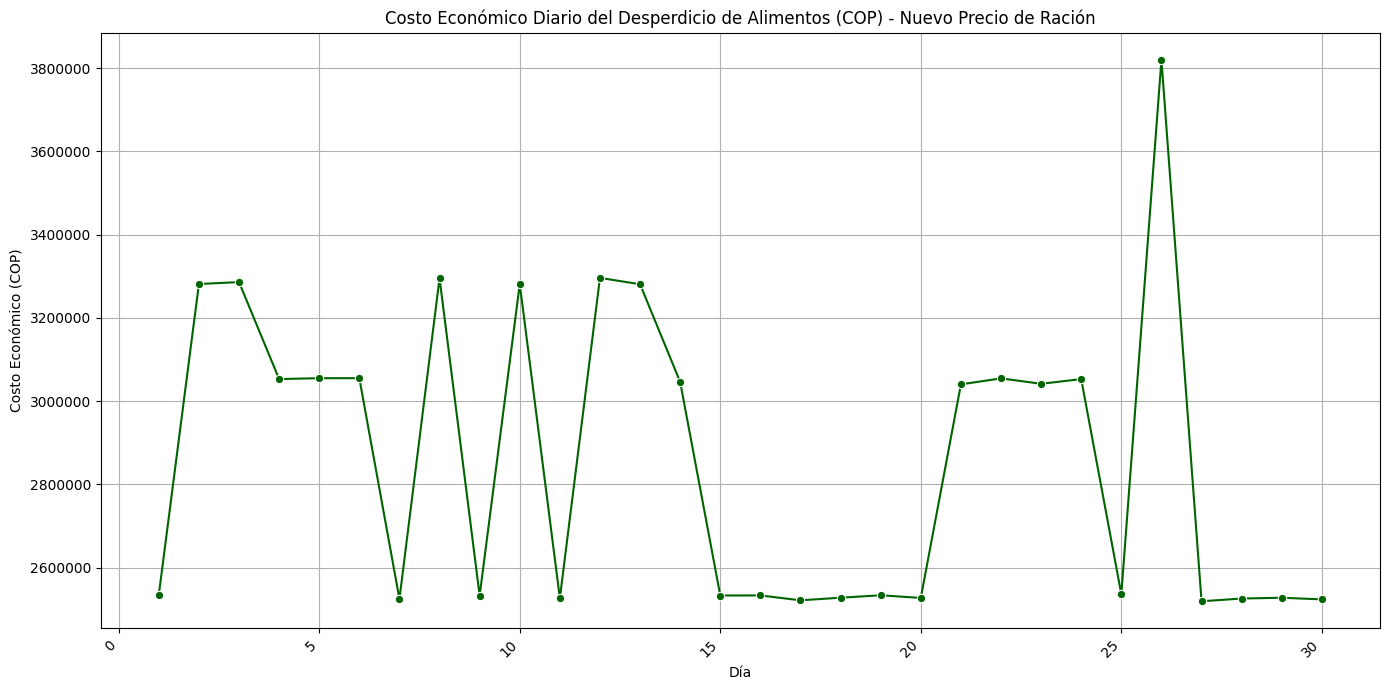

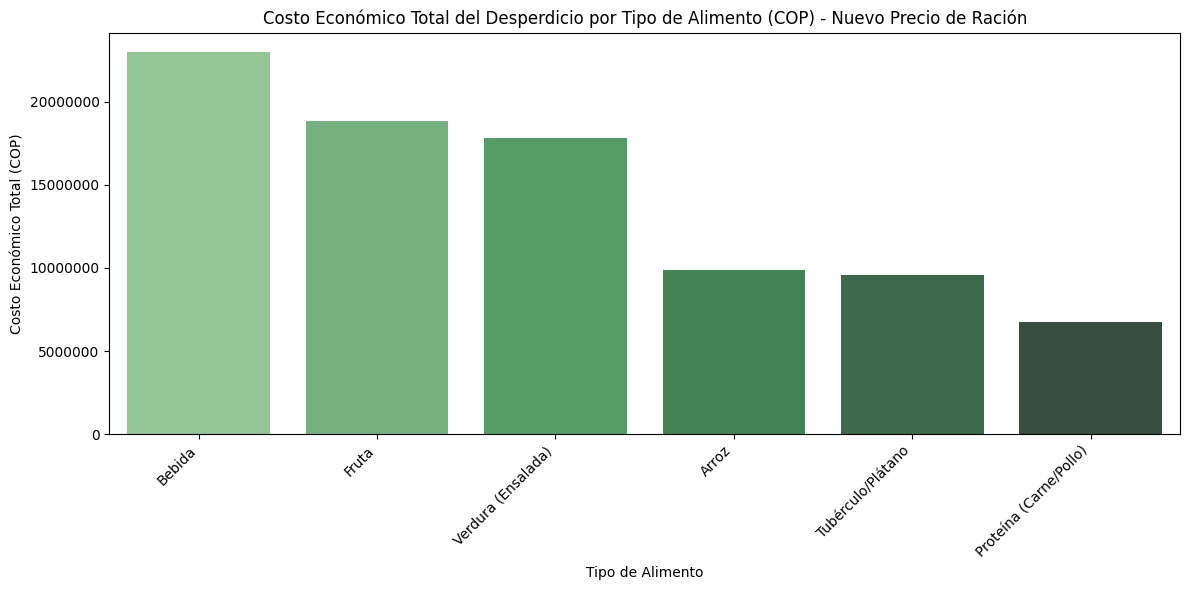

In [46]:
# Visualizar el costo económico diario del desperdicio (con el nuevo precio)
plt.figure(figsize=(14, 7))
sns.lineplot(x=daily_economic_loss_nuevo.index, y=daily_economic_loss_nuevo.values, marker='o', color='darkgreen')
plt.title('Costo Económico Diario del Desperdicio de Alimentos (COP) - Nuevo Precio de Ración')
plt.xlabel('Día')
plt.ylabel('Costo Económico (COP)')
plt.grid(True)
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

# Visualizar el costo económico total por tipo de alimento (con el nuevo precio)
# Aunque el precio por gramo es uniforme, la distribución por alimento sigue siendo relevante por la cantidad desperdiciada.
economic_loss_per_food_nuevo = df_economic.groupby('Alimento')['Costo_Economico_Perdido_Estudiante_Nuevo'].sum().sort_values(ascending=False)

# Convertir la serie a DataFrame para usar con 'data' en seaborn
df_economic_loss_per_food_nuevo = economic_loss_per_food_nuevo.reset_index()
df_economic_loss_per_food_nuevo.columns = ['Alimento', 'Costo_Economico_Total']

plt.figure(figsize=(12, 6))
sns.barplot(x='Alimento', y='Costo_Economico_Total', data=df_economic_loss_per_food_nuevo, palette='Greens_d', hue='Alimento', legend=False)
plt.title('Costo Económico Total del Desperdicio por Tipo de Alimento (COP) - Nuevo Precio de Ración')
plt.xlabel('Tipo de Alimento')
plt.ylabel('Costo Económico Total (COP)')
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

### Conclusiones del Impacto Económico del Desperdicio (con Precio de Ración de $6810 COP)

Considerando el precio de una ración servida de **$6810 COP**, hemos cuantificado el impacto económico del desperdicio de alimentos:

1.  **Costo Promedio por Gramo de Ración:** El precio promedio de cada gramo de alimento en la ración es de aproximadamente **10.01 COP/gramo**.

2.  **Desperdicio Económico por Estudiante:**
    *   **Diario:** Si un estudiante promedio desperdicia aproximadamente **114.33 gramos** al día (como se calculó previamente), esto representa un costo económico diario de **~$1,144 COP** por estudiante ($114.33 gramos * 10.01 COP/gramo).
    *   **Mensual (30 días):** El costo económico promedio por estudiante debido al desperdicio durante los 30 días es de **$34,349.70 COP**.

3.  **Impacto Mensual en el Servicio del Restaurante Escolar:**
    *   El **costo económico TOTAL del desperdicio** para el servicio de restaurante escolar durante los 30 días es de **$85,874,246.90 COP**.

Estos datos resaltan la magnitud del costo asociado al desperdicio de alimentos. El restaurante escolar está perdiendo una cantidad significativa de dinero debido a los alimentos que no son consumidos, lo que sugiere una oportunidad clara para implementar estrategias de reducción de desperdicio que no solo beneficiarían el medio ambiente y la nutrición, sino también la sostenibilidad financiera del programa.